# Lab Task 1: Advanced Edge Detection Techniques

## Import Libraries

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Load Image

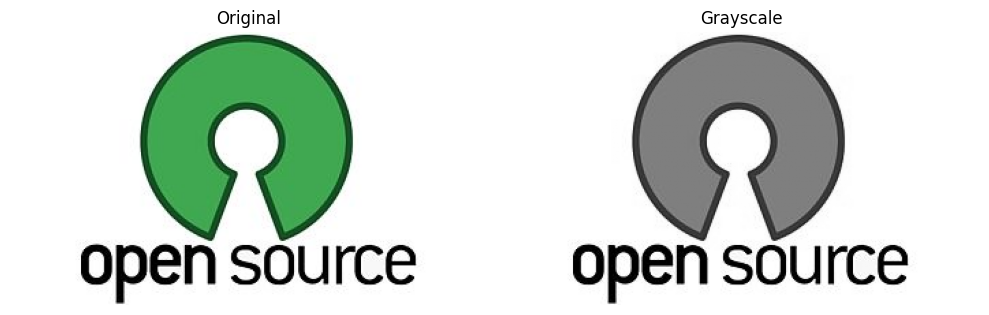

In [7]:
img_bgr  = cv2.imread('../CVLab02/assets/opencv.jpg')
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(img_rgb);              
plt.title('Original');  plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(img_gray, cmap='gray'); 
plt.title('Grayscale'); plt.axis('off')
plt.tight_layout(); plt.show()

## Canny Edge Detection

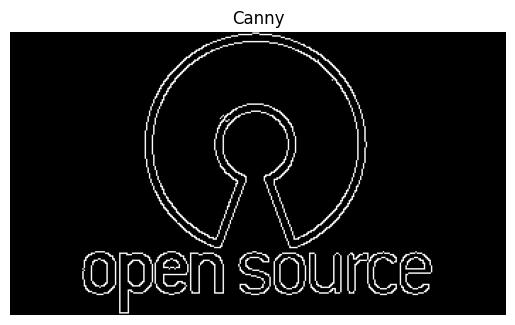

In [8]:
canny = cv2.Canny(img_gray, 50, 150)

plt.imshow(canny, cmap='gray'); plt.title('Canny'); plt.axis('off'); plt.show()

## Sobel Edge Detection

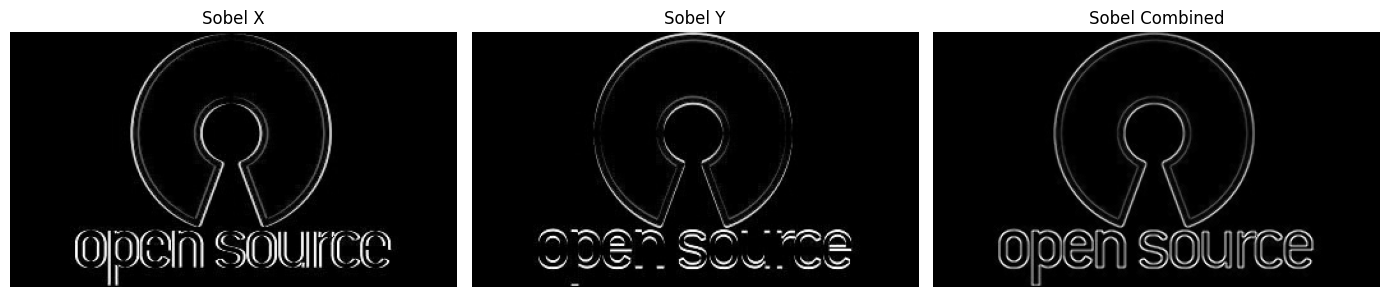

In [11]:
sobel_x = cv2.convertScaleAbs(cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=1))
sobel_y = cv2.convertScaleAbs(cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=1))
sobel   = cv2.addWeighted(sobel_x, 0.5, sobel_y, 0.5, 0)

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, img, t in zip(ax, [sobel_x, sobel_y, sobel], ['Sobel X', 'Sobel Y', 'Sobel Combined']):
    a.imshow(img, cmap='gray'); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()

## Scharr Edge Detection

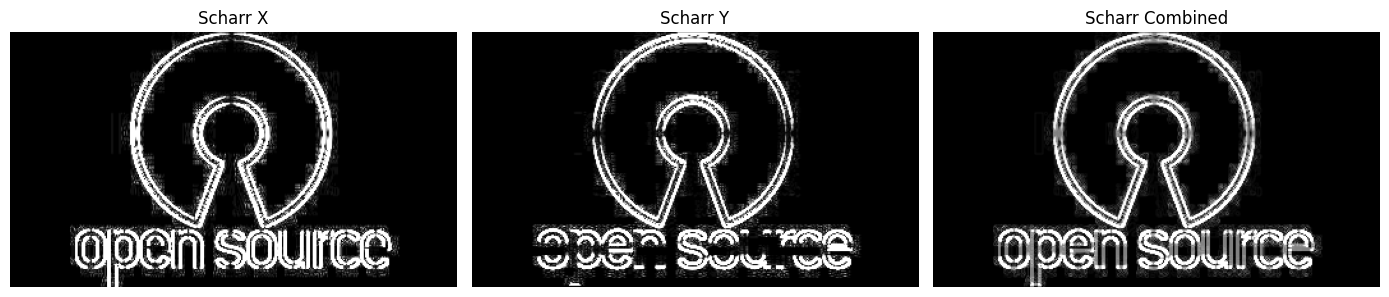

In [13]:
scharr_x = cv2.convertScaleAbs(cv2.Scharr(img_gray, cv2.CV_64F, 1, 0))
scharr_y = cv2.convertScaleAbs(cv2.Scharr(img_gray, cv2.CV_64F, 0, 1))
scharr   = cv2.addWeighted(scharr_x, 0.5, scharr_y, 0.5, 0)

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, img, t in zip(ax, [scharr_x, scharr_y, scharr], ['Scharr X', 'Scharr Y', 'Scharr Combined']):
    a.imshow(img, cmap='gray'); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()

## Laplacian Edge Detection

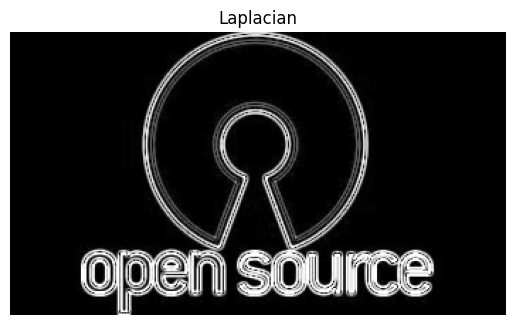

In [12]:
blurred     = cv2.GaussianBlur(img_gray, (3, 3), 0)
laplacian   = cv2.convertScaleAbs(cv2.Laplacian(blurred, cv2.CV_64F, ksize=3))

plt.imshow(laplacian, cmap='gray'); plt.title('Laplacian'); plt.axis('off'); plt.show()

## Comparative Analysis

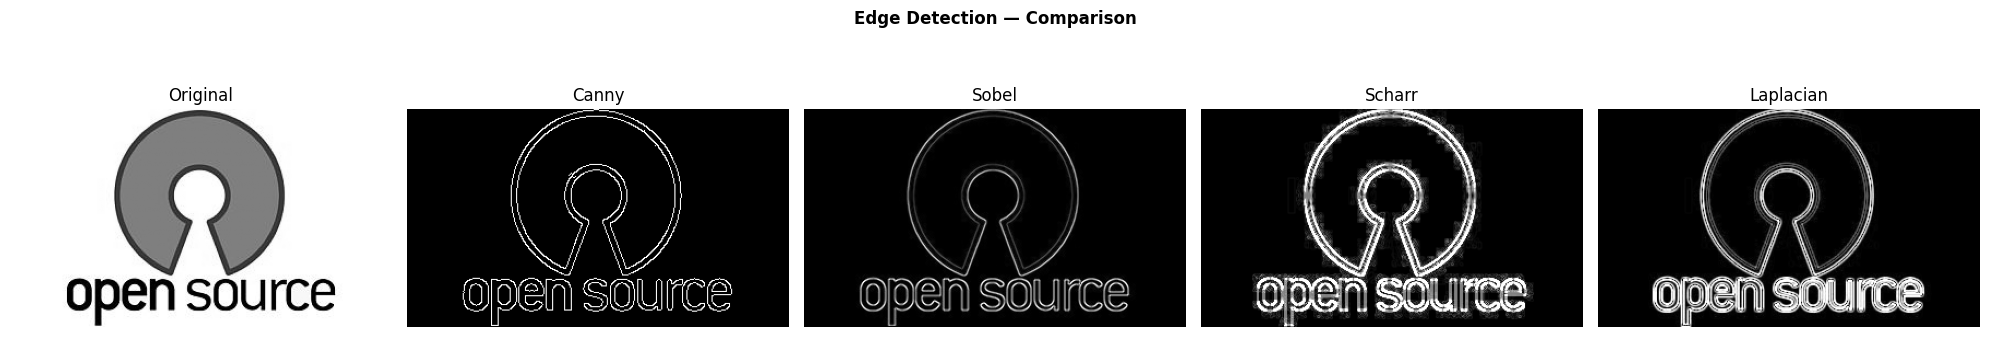

Method        Edge Pixels   % of Image
--------------------------------------
Canny               3,006        4.29%
Sobel              18,907       27.01%
Scharr             22,873       32.68%
Laplacian          22,301       31.86%


In [14]:
results = [img_gray, canny, sobel, scharr, laplacian]
labels  = ['Original', 'Canny', 'Sobel', 'Scharr', 'Laplacian']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Edge Detection — Comparison', fontweight='bold')
for ax, img, lbl in zip(axes, results, labels):
    ax.imshow(img, cmap='gray'); ax.set_title(lbl); ax.axis('off')
plt.tight_layout(); plt.show()

print(f"{'Method':<12} {'Edge Pixels':>12} {'% of Image':>12}")
print('-' * 38)
for lbl, img in zip(labels[1:], results[1:]):
    n = np.count_nonzero(img)
    print(f"{lbl:<12} {n:>12,} {100*n/img_gray.size:>11.2f}%")